# GeMS_A vs GeMS_A10: Comprehensive Comparison

This notebook compares the two GeMS dataset variants:

| Variant | Description | Size |
|---------|-------------|------|
| **GeMS_A** | All spectra from high-quality (mostly Orbitrap) sources, no cluster limit | 24.4 GB |
| **GeMS_A10** | Same quality filter but deduplicated: max 10 spectra per cluster | 14.6 GB |

The cluster deduplication in GeMS_A10 removes redundant spectra, producing a higher-quality
training set. The [DreaMS paper](https://www.nature.com/articles/s41587-025-02663-3) found that
model performance scales with high-quality clustered data.

**Sections:**
1. Download and load both HDF5 files
2. Schema comparison (keys, shapes, dtypes)
3. Dataset size and deduplication ratio
4. Precursor m/z distribution comparison
5. Retention time distribution comparison
6. Peak count and intensity distributions
7. Spectral diversity analysis
8. Pipeline processing comparison (input_pipeline.py logic)
9. Processed feature distributions
10. Summary and recommendations

In [1]:
import sys
sys.path.insert(0, "..")

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from huggingface_hub import hf_hub_download

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download and Load

In [2]:
DATA_DIR = Path("../data/data/GeMS_A")
GEMS_A_PATH = DATA_DIR / "GeMS_A.hdf5"
GEMS_A10_PATH = DATA_DIR / "GeMS_A10.hdf5"

HF_REPO = "roman-bushuiev/GeMS"

# GeMS_A should already be downloaded by the pipeline
assert GEMS_A_PATH.exists(), f"GeMS_A.hdf5 not found at {GEMS_A_PATH}"
print(f"GeMS_A.hdf5: {GEMS_A_PATH.stat().st_size / 1e9:.2f} GB")

# Download GeMS_A10 if not present
if not GEMS_A10_PATH.exists():
    print("Downloading GeMS_A10.hdf5 ...")
    hf_hub_download(
        repo_id=HF_REPO,
        filename="data/GeMS_A/GeMS_A10.hdf5",
        repo_type="dataset",
        local_dir=str(DATA_DIR.parent.parent),
    )
    print("Done.")
print(f"GeMS_A10.hdf5: {GEMS_A10_PATH.stat().st_size / 1e9:.2f} GB")

GeMS_A.hdf5: 24.45 GB


Done.
GeMS_A10.hdf5: 14.63 GB


In [3]:
fa = h5py.File(GEMS_A_PATH, "r")
f10 = h5py.File(GEMS_A10_PATH, "r")

print("Opened both files successfully.")
print(f"GeMS_A  keys: {list(fa.keys())}")
print(f"GeMS_A10 keys: {list(f10.keys())}")

Opened both files successfully.
GeMS_A  keys: ['RT', 'charge', 'instrument accuracy est.', 'name', 'precursor_mz', 'spectrum']
GeMS_A10 keys: ['RT', 'charge', 'instrument accuracy est.', 'lsh', 'name', 'precursor_mz', 'spectrum']


## 2. Schema Comparison

In [4]:
def describe_hdf5(f: h5py.File, name: str) -> pd.DataFrame:
    rows = []
    for key in sorted(f.keys()):
        ds = f[key]
        rows.append({
            "dataset": name,
            "key": key,
            "shape": ds.shape,
            "dtype": str(ds.dtype),
            "size_MB": ds.nbytes / 1e6 if hasattr(ds, "nbytes") else np.prod(ds.shape) * ds.dtype.itemsize / 1e6,
        })
    return pd.DataFrame(rows)

schema_a = describe_hdf5(fa, "GeMS_A")
schema_10 = describe_hdf5(f10, "GeMS_A10")
schema = pd.concat([schema_a, schema_10], ignore_index=True)

print("Schema comparison:")
display(schema.pivot_table(index="key", columns="dataset", values=["shape", "dtype"], aggfunc="first"))

Schema comparison:


dtype                        shape  \
dataset                    GeMS_A GeMS_A10              GeMS_A   
key                                                              
RT                        float32  float32         (41951922,)   
charge                       int8     int8         (41951922,)   
instrument accuracy est.  float32  float32         (41951922,)   
lsh                           NaN    int64                 NaN   
name                       object   object         (41951922,)   
precursor_mz              float32  float32         (41951922,)   
spectrum                  float64  float64  (41951922, 2, 128)   

                                              
dataset                             GeMS_A10  
key                                           
RT                               (23517534,)  
charge                           (23517534,)  
instrument accuracy est.         (23517534,)  
lsh                              (23517534,)  
name                             (23517534,)  
precursor_mz                     (23517534,)  
spectrum                  (23517534, 2, 128)

## 3. Dataset Size and Deduplication Ratio

In [5]:
n_a = fa["spectrum"].shape[0]
n_10 = f10["spectrum"].shape[0]
num_peaks_a = fa["spectrum"].shape[2] if fa["spectrum"].ndim == 3 else fa["spectrum"].shape[1]
num_peaks_10 = f10["spectrum"].shape[2] if f10["spectrum"].ndim == 3 else f10["spectrum"].shape[1]

print(f"GeMS_A  spectra: {n_a:>12,}")
print(f"GeMS_A10 spectra: {n_10:>12,}")
print(f"Deduplication ratio: {n_10 / n_a * 100:.1f}% retained")
print(f"Removed by clustering: {n_a - n_10:,} spectra ({(n_a - n_10) / n_a * 100:.1f}%)")
print(f"\nSpectrum array shapes:")
print(f"  GeMS_A:  {fa['spectrum'].shape}")
print(f"  GeMS_A10: {f10['spectrum'].shape}")

GeMS_A  spectra:   41,951,922
GeMS_A10 spectra:   23,517,534
Deduplication ratio: 56.1% retained
Removed by clustering: 18,434,388 spectra (43.9%)

Spectrum array shapes:
  GeMS_A:  (41951922, 2, 128)
  GeMS_A10: (23517534, 2, 128)


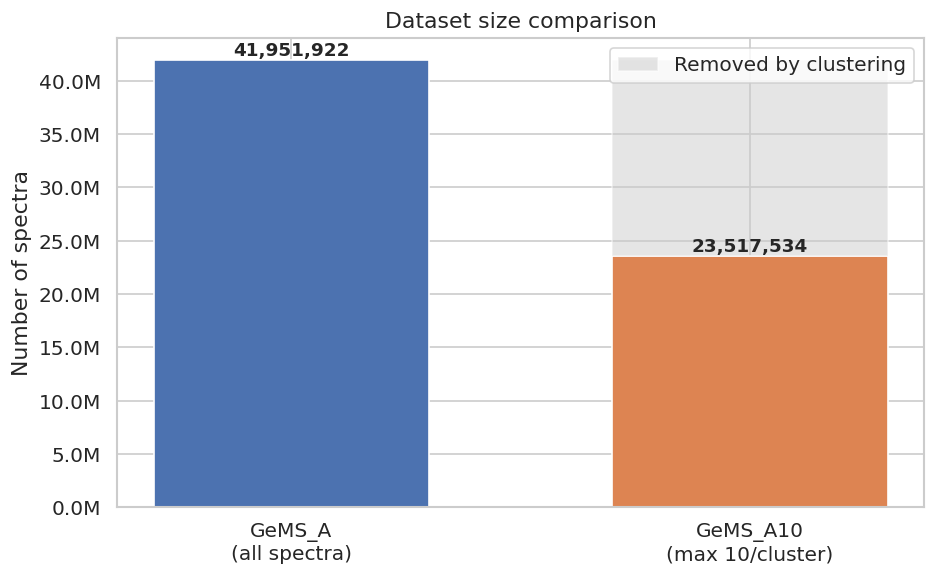

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["GeMS_A", "GeMS_A10", "Removed\n(duplicates)"]
sizes = [n_a, n_10, n_a - n_10]
colors = ["#4C72B0", "#DD8452", "#CCCCCC"]

bars = ax.bar([0, 1], [n_a, n_10], color=colors[:2], edgecolor="white", width=0.6)
ax.bar([1], [n_a - n_10], bottom=[n_10], color=colors[2], edgecolor="white",
       width=0.6, alpha=0.5, label="Removed by clustering")

ax.set_xticks([0, 1])
ax.set_xticklabels(["GeMS_A\n(all spectra)", "GeMS_A10\n(max 10/cluster)"])
ax.set_ylabel("Number of spectra")
ax.set_title("Dataset size comparison")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M"))

for bar, val in zip(bars, [n_a, n_10]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + n_a * 0.01,
            f"{val:,}", ha="center", fontsize=11, fontweight="bold")

ax.legend()
fig.tight_layout()
plt.show()

## 4. Precursor m/z Distribution Comparison

Compare the precursor mass distributions to see if cluster deduplication changes the mass range coverage.

In [7]:
# Load precursor_mz (small arrays, fit in memory)
prec_a = np.asarray(fa["precursor_mz"], dtype=np.float32)
prec_10 = np.asarray(f10["precursor_mz"], dtype=np.float32)

print(f"GeMS_A  precursor_mz: shape={prec_a.shape}, range=[{prec_a.min():.2f}, {prec_a.max():.2f}]")
print(f"GeMS_A10 precursor_mz: shape={prec_10.shape}, range=[{prec_10.min():.2f}, {prec_10.max():.2f}]")

GeMS_A  precursor_mz: shape=(41951922,), range=[55.05, 999.98]
GeMS_A10 precursor_mz: shape=(23517534,), range=[55.05, 999.98]


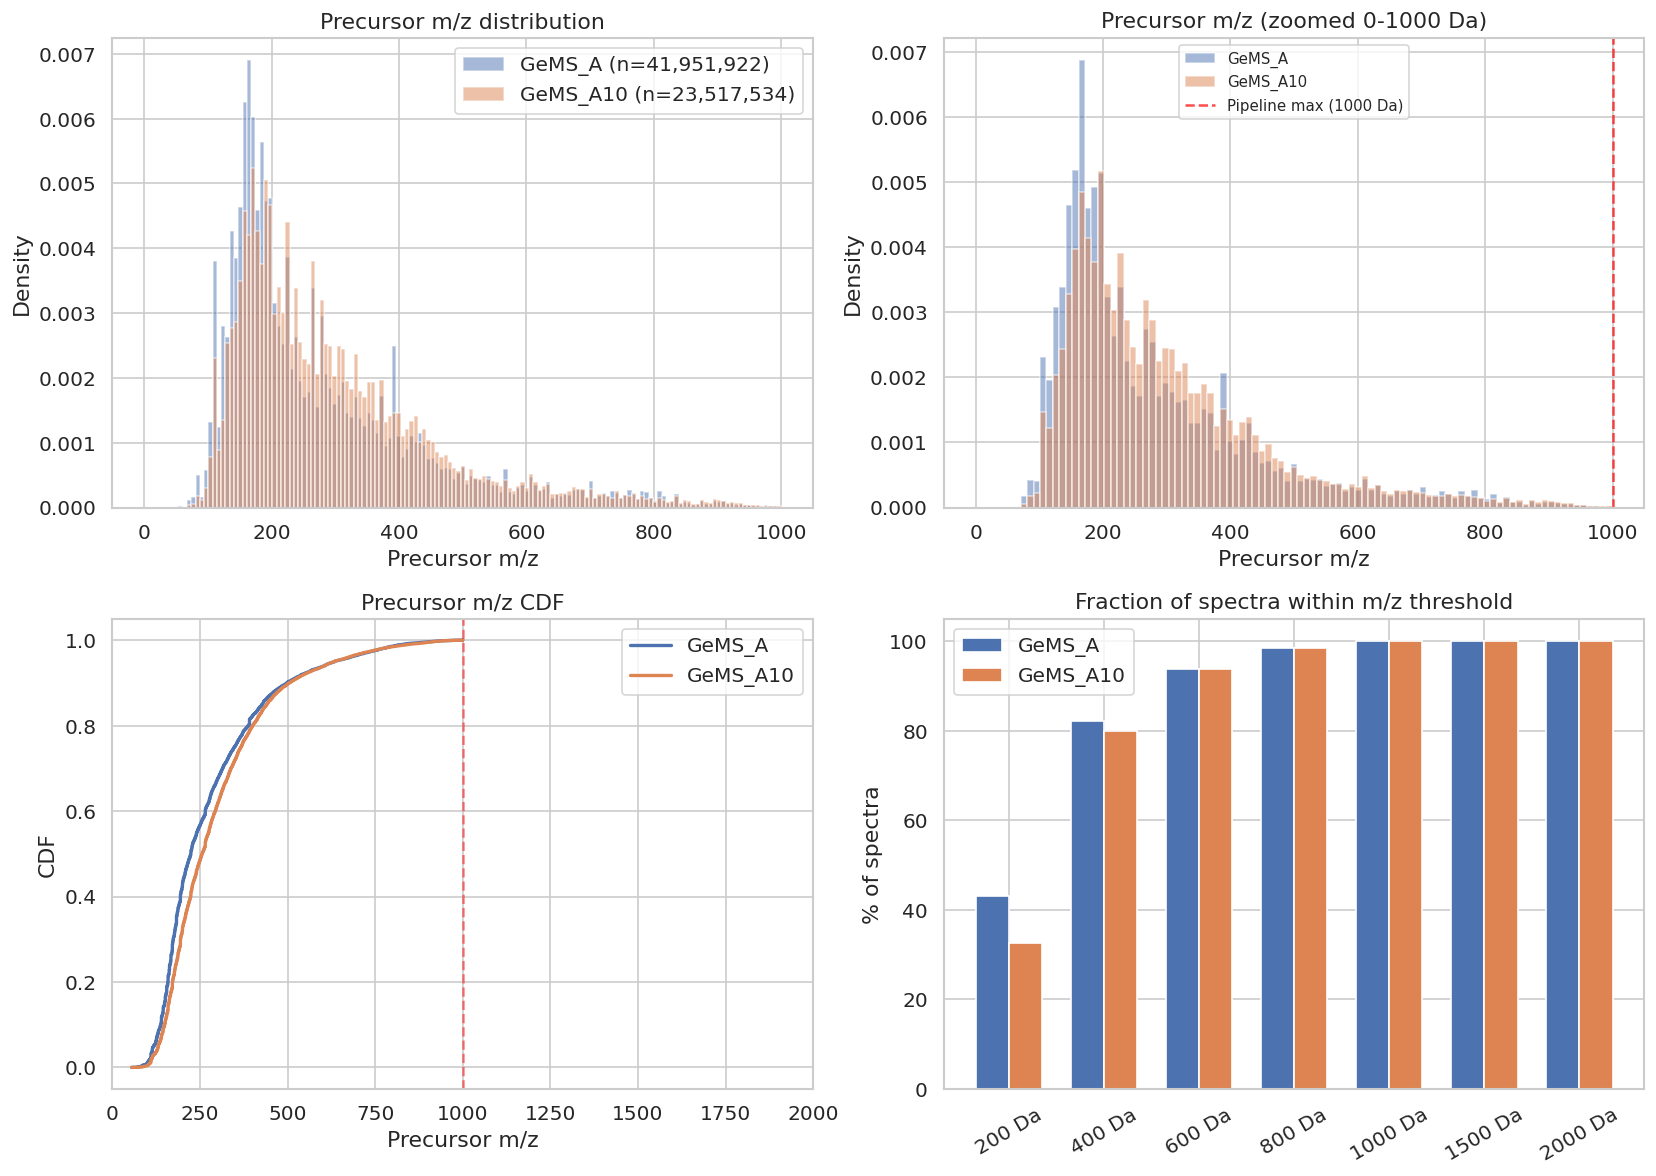


Spectra with precursor_mz <= 1000:
  GeMS_A:  41,951,922 (100.0%)
  GeMS_A10: 23,517,534 (100.0%)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) Overlaid histograms
ax = axes[0, 0]
bins = np.linspace(0, min(prec_a.max(), 2000), 150)
ax.hist(prec_a, bins=bins, alpha=0.5, density=True, label=f"GeMS_A (n={n_a:,})", color="#4C72B0")
ax.hist(prec_10, bins=bins, alpha=0.5, density=True, label=f"GeMS_A10 (n={n_10:,})", color="#DD8452")
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Density")
ax.set_title("Precursor m/z distribution")
ax.legend()

# (0,1) Zoomed to 0-1000 (our pipeline range)
ax = axes[0, 1]
bins_zoom = np.linspace(0, 1000, 100)
ax.hist(prec_a[prec_a <= 1000], bins=bins_zoom, alpha=0.5, density=True,
        label="GeMS_A", color="#4C72B0")
ax.hist(prec_10[prec_10 <= 1000], bins=bins_zoom, alpha=0.5, density=True,
        label="GeMS_A10", color="#DD8452")
ax.axvline(1000, color="red", ls="--", alpha=0.7, label="Pipeline max (1000 Da)")
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("Density")
ax.set_title("Precursor m/z (zoomed 0-1000 Da)")
ax.legend(fontsize=9)

# (1,0) CDF comparison
ax = axes[1, 0]
for arr, label, color in [(prec_a, "GeMS_A", "#4C72B0"), (prec_10, "GeMS_A10", "#DD8452")]:
    sorted_vals = np.sort(arr)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    # Subsample for plotting
    idx = np.linspace(0, len(sorted_vals) - 1, 5000, dtype=int)
    ax.plot(sorted_vals[idx], cdf[idx], label=label, color=color, lw=2)
ax.set_xlabel("Precursor m/z")
ax.set_ylabel("CDF")
ax.set_title("Precursor m/z CDF")
ax.set_xlim(0, 2000)
ax.axvline(1000, color="red", ls="--", alpha=0.5)
ax.legend()

# (1,1) Fraction in pipeline range
ax = axes[1, 1]
thresholds = [200, 400, 600, 800, 1000, 1500, 2000]
frac_a = [(prec_a <= t).mean() * 100 for t in thresholds]
frac_10 = [(prec_10 <= t).mean() * 100 for t in thresholds]

x = np.arange(len(thresholds))
w = 0.35
ax.bar(x - w/2, frac_a, w, label="GeMS_A", color="#4C72B0")
ax.bar(x + w/2, frac_10, w, label="GeMS_A10", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels([f"{t} Da" for t in thresholds], rotation=30)
ax.set_ylabel("% of spectra")
ax.set_title("Fraction of spectra within m/z threshold")
ax.legend()

fig.tight_layout()
plt.show()

print(f"\nSpectra with precursor_mz <= 1000:")
print(f"  GeMS_A:  {(prec_a <= 1000).sum():,} ({(prec_a <= 1000).mean()*100:.1f}%)")
print(f"  GeMS_A10: {(prec_10 <= 1000).sum():,} ({(prec_10 <= 1000).mean()*100:.1f}%)")

## 5. Retention Time Distribution

Valid RT spectra:
  GeMS_A:  41,951,908 / 41,951,922 (100.0%)
  GeMS_A10: 23,517,529 / 23,517,534 (100.0%)


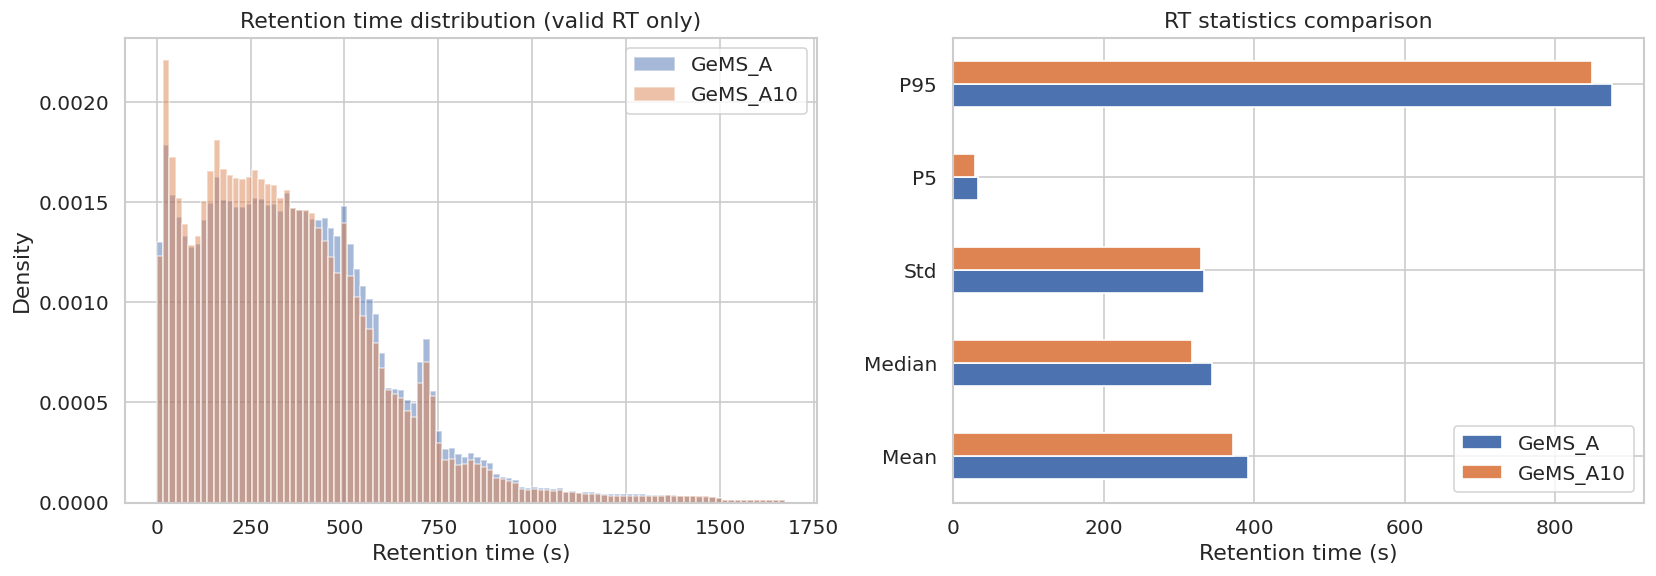


RT statistics:


,GeMS_A,GeMS_A10
Mean,392.309998,372.309998
Median,343.720001,317.040009
Std,333.769989,329.799988
P5,32.950001,29.959999
P95,874.570007,849.130005


In [9]:
rt_a = np.asarray(fa["RT"], dtype=np.float32)
rt_10 = np.asarray(f10["RT"], dtype=np.float32)

# Filter valid RTs (pipeline does: isfinite & > 0)
valid_rt_a = rt_a[np.isfinite(rt_a) & (rt_a > 0)]
valid_rt_10 = rt_10[np.isfinite(rt_10) & (rt_10 > 0)]

print(f"Valid RT spectra:")
print(f"  GeMS_A:  {len(valid_rt_a):,} / {len(rt_a):,} ({len(valid_rt_a)/len(rt_a)*100:.1f}%)")
print(f"  GeMS_A10: {len(valid_rt_10):,} / {len(rt_10):,} ({len(valid_rt_10)/len(rt_10)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RT histogram
ax = axes[0]
bins_rt = np.linspace(0, min(np.percentile(valid_rt_a, 99), np.percentile(valid_rt_10, 99)), 100)
ax.hist(valid_rt_a, bins=bins_rt, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(valid_rt_10, bins=bins_rt, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Retention time (s)")
ax.set_ylabel("Density")
ax.set_title("Retention time distribution (valid RT only)")
ax.legend()

# RT statistics comparison
ax = axes[1]
stats = pd.DataFrame({
    "GeMS_A": [valid_rt_a.mean(), np.median(valid_rt_a), valid_rt_a.std(),
               np.percentile(valid_rt_a, 5), np.percentile(valid_rt_a, 95)],
    "GeMS_A10": [valid_rt_10.mean(), np.median(valid_rt_10), valid_rt_10.std(),
                 np.percentile(valid_rt_10, 5), np.percentile(valid_rt_10, 95)],
}, index=["Mean", "Median", "Std", "P5", "P95"])

stats.plot.barh(ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xlabel("Retention time (s)")
ax.set_title("RT statistics comparison")

fig.tight_layout()
plt.show()

print("\nRT statistics:")
display(stats.round(2))

## 6. Peak Count and Intensity Distributions

Analyze the raw spectrum arrays. Each spectrum is stored as `[2, num_peaks]` with row 0 = m/z, row 1 = intensity.

In [10]:
# Sample a subset for detailed analysis (full arrays are too large)
SAMPLE_SIZE = 100_000

idx_a = np.random.choice(n_a, size=min(SAMPLE_SIZE, n_a), replace=False)
idx_a.sort()
idx_10 = np.random.choice(n_10, size=min(SAMPLE_SIZE, n_10), replace=False)
idx_10.sort()

print(f"Sampling {len(idx_a):,} spectra from GeMS_A and {len(idx_10):,} from GeMS_A10")

# Load sampled spectra
spec_a = fa["spectrum"][idx_a]  # [N, 2, num_peaks]
spec_10 = f10["spectrum"][idx_10]

print(f"GeMS_A  sample: {spec_a.shape}, dtype={spec_a.dtype}")
print(f"GeMS_A10 sample: {spec_10.shape}, dtype={spec_10.dtype}")

Sampling 100,000 spectra from GeMS_A and 100,000 from GeMS_A10


GeMS_A  sample: (100000, 2, 128), dtype=float64
GeMS_A10 sample: (100000, 2, 128), dtype=float64


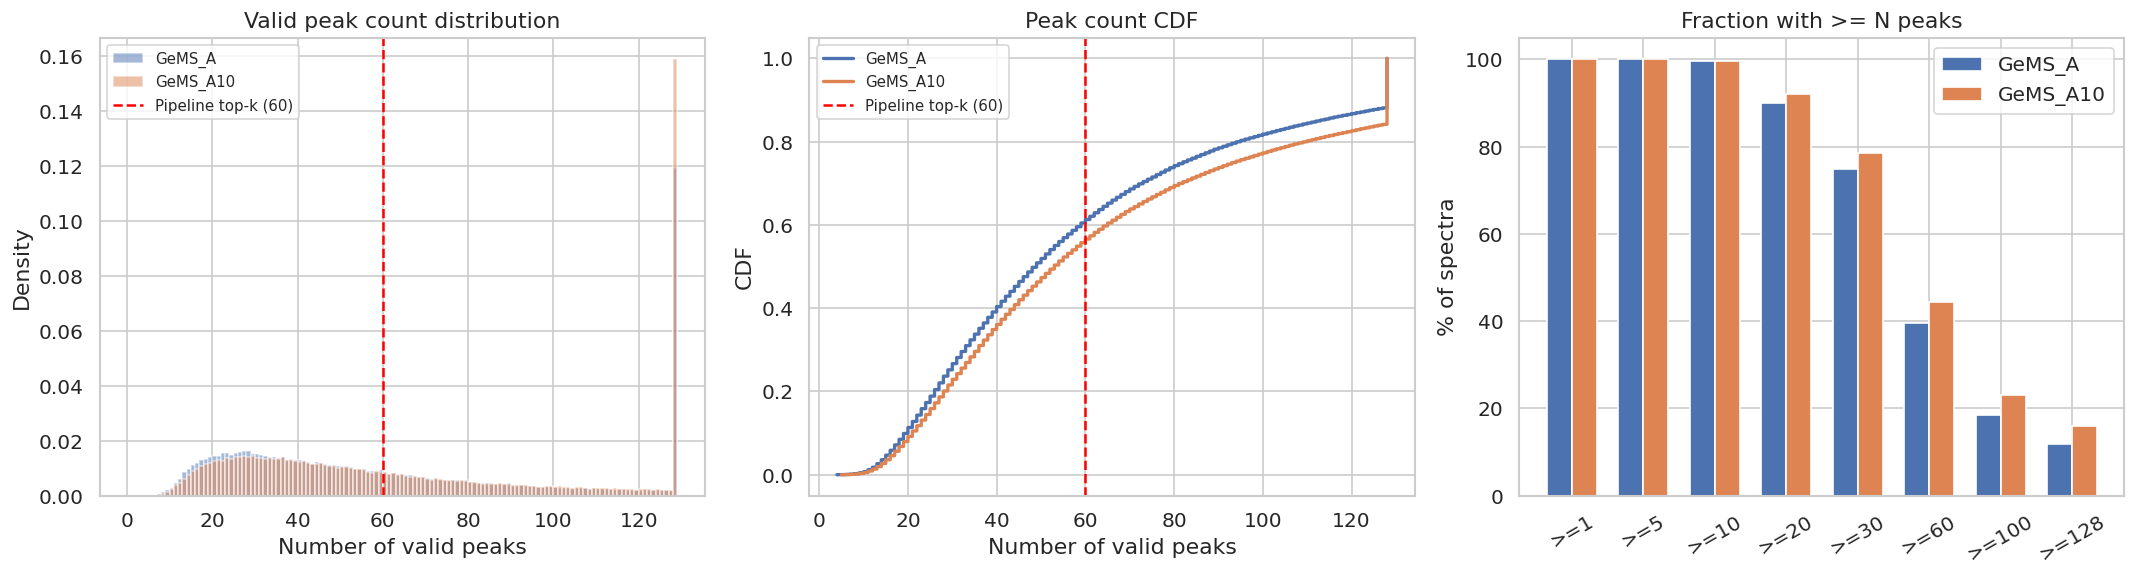


Peak count statistics:
  GeMS_A: mean=59.1, median=49, min=4, max=128, >=60: 39.5%
  GeMS_A10: mean=63.9, median=53, min=5, max=128, >=60: 44.3%


In [11]:
# Count valid (non-zero) peaks per spectrum
def count_valid_peaks(spectra: np.ndarray) -> np.ndarray:
    """Count peaks with non-zero intensity."""
    intensity = spectra[:, 1, :]  # [N, num_peaks]
    return (intensity > 0).sum(axis=1)

peaks_a = count_valid_peaks(spec_a)
peaks_10 = count_valid_peaks(spec_10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Peak count histogram
ax = axes[0]
max_peaks = max(peaks_a.max(), peaks_10.max())
bins_p = np.arange(0, min(max_peaks + 2, 130))
ax.hist(peaks_a, bins=bins_p, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(peaks_10, bins=bins_p, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.axvline(60, color="red", ls="--", label="Pipeline top-k (60)")
ax.set_xlabel("Number of valid peaks")
ax.set_ylabel("Density")
ax.set_title("Valid peak count distribution")
ax.legend(fontsize=9)

# Peak count CDF
ax = axes[1]
for arr, label, color in [(peaks_a, "GeMS_A", "#4C72B0"), (peaks_10, "GeMS_A10", "#DD8452")]:
    sorted_p = np.sort(arr)
    cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    ax.plot(sorted_p, cdf, label=label, color=color, lw=2)
ax.axvline(60, color="red", ls="--", label="Pipeline top-k (60)")
ax.set_xlabel("Number of valid peaks")
ax.set_ylabel("CDF")
ax.set_title("Peak count CDF")
ax.legend(fontsize=9)

# Spectra with >= 60 peaks (our pipeline uses top-60)
ax = axes[2]
thresholds_pk = [1, 5, 10, 20, 30, 60, 100, 128]
frac_pk_a = [(peaks_a >= t).mean() * 100 for t in thresholds_pk]
frac_pk_10 = [(peaks_10 >= t).mean() * 100 for t in thresholds_pk]
x = np.arange(len(thresholds_pk))
w = 0.35
ax.bar(x - w/2, frac_pk_a, w, label="GeMS_A", color="#4C72B0")
ax.bar(x + w/2, frac_pk_10, w, label="GeMS_A10", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels([f">={t}" for t in thresholds_pk], rotation=30)
ax.set_ylabel("% of spectra")
ax.set_title("Fraction with >= N peaks")
ax.legend()

fig.tight_layout()
plt.show()

print(f"\nPeak count statistics:")
for name, arr in [("GeMS_A", peaks_a), ("GeMS_A10", peaks_10)]:
    print(f"  {name}: mean={arr.mean():.1f}, median={np.median(arr):.0f}, "
          f"min={arr.min()}, max={arr.max()}, >=60: {(arr>=60).mean()*100:.1f}%")

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


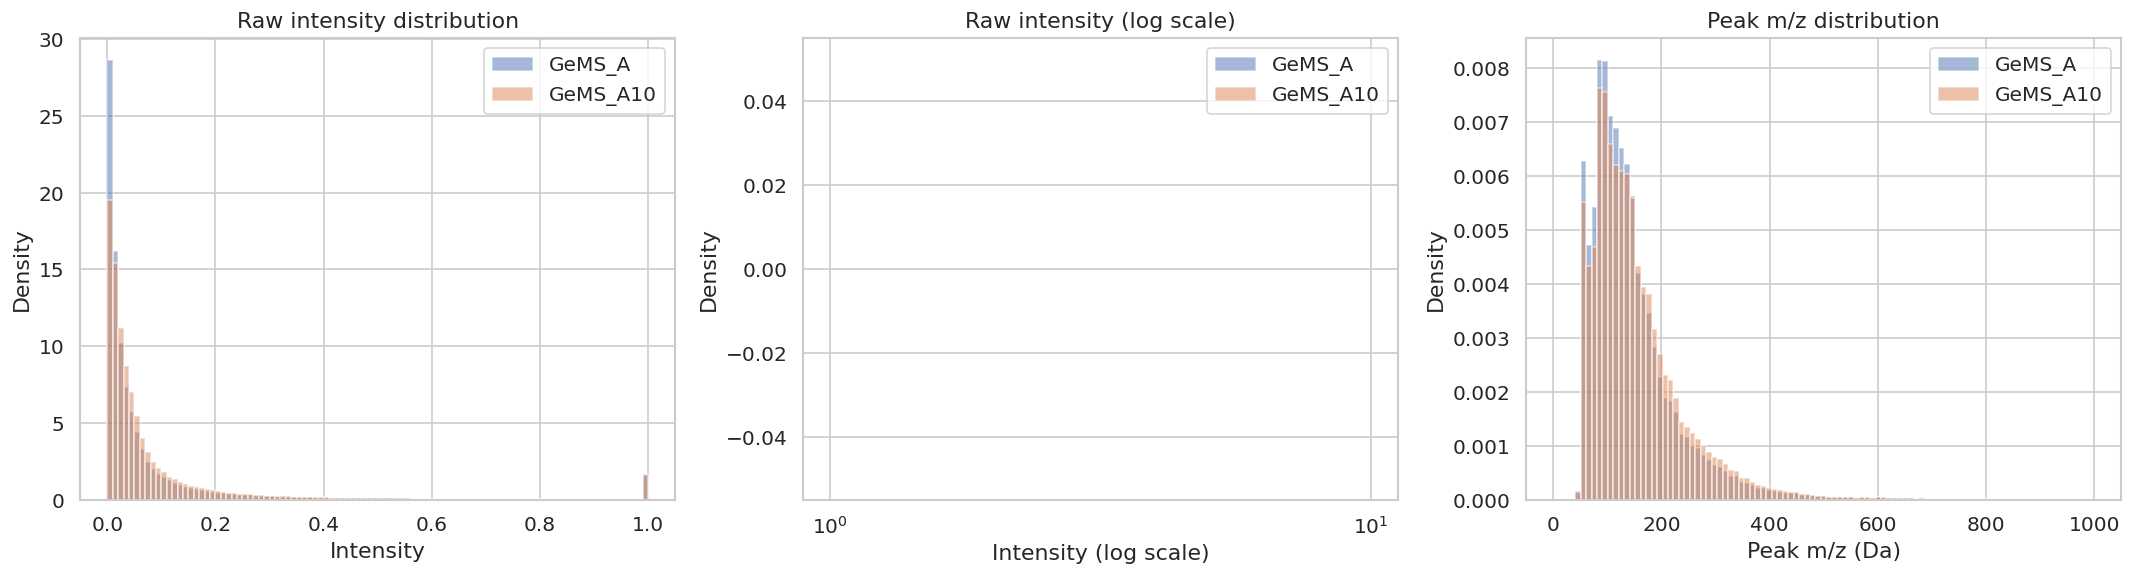

In [12]:
# Intensity distribution analysis
def get_valid_intensities(spectra: np.ndarray, max_samples: int = 500_000) -> np.ndarray:
    """Extract all non-zero intensity values, subsampled if too many."""
    intensities = spectra[:, 1, :].ravel()
    valid = intensities[intensities > 0]
    if len(valid) > max_samples:
        valid = np.random.choice(valid, max_samples, replace=False)
    return valid

int_a = get_valid_intensities(spec_a)
int_10 = get_valid_intensities(spec_10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear scale
ax = axes[0]
ax.hist(int_a, bins=100, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(int_10, bins=100, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Intensity")
ax.set_ylabel("Density")
ax.set_title("Raw intensity distribution")
ax.legend()

# Log scale
ax = axes[1]
log_bins = np.logspace(np.log10(max(int_a.min(), 1)), np.log10(int_a.max()), 100)
ax.hist(int_a, bins=log_bins, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(int_10, bins=log_bins, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xscale("log")
ax.set_xlabel("Intensity (log scale)")
ax.set_ylabel("Density")
ax.set_title("Raw intensity (log scale)")
ax.legend()

# M/z range of peaks
ax = axes[2]
mz_a = spec_a[:, 0, :].ravel()
mz_a = mz_a[mz_a > 0]
mz_10 = spec_10[:, 0, :].ravel()
mz_10 = mz_10[mz_10 > 0]
if len(mz_a) > 500_000:
    mz_a = np.random.choice(mz_a, 500_000, replace=False)
if len(mz_10) > 500_000:
    mz_10 = np.random.choice(mz_10, 500_000, replace=False)

bins_mz = np.linspace(0, 1000, 100)
ax.hist(mz_a, bins=bins_mz, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(mz_10, bins=bins_mz, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Peak m/z (Da)")
ax.set_ylabel("Density")
ax.set_title("Peak m/z distribution")
ax.legend()

fig.tight_layout()
plt.show()

## 7. Spectral Diversity Analysis

Compare spectral diversity between the two datasets using:
- Base peak m/z distribution (the most intense peak)
- Total ion current (sum of intensities) distribution
- Spectral entropy

In [13]:
def spectral_metrics(spectra: np.ndarray) -> dict[str, np.ndarray]:
    """Compute per-spectrum summary metrics."""
    mz = spectra[:, 0, :]         # [N, P]
    intensity = spectra[:, 1, :]   # [N, P]
    valid = intensity > 0
    
    # Base peak m/z (m/z of most intense peak)
    bp_idx = intensity.argmax(axis=1)  # [N]
    base_peak_mz = mz[np.arange(len(mz)), bp_idx]
    
    # Total ion current
    tic = intensity.sum(axis=1)
    
    # Max intensity
    max_int = intensity.max(axis=1)
    
    # Spectral entropy: -sum(p * log(p)) where p = intensity / sum(intensity)
    tic_safe = np.clip(tic, 1e-12, None)
    p = intensity / tic_safe[:, None]
    p = np.clip(p, 1e-12, None)
    entropy = -np.sum(np.where(valid, p * np.log2(p), 0.0), axis=1)
    
    # M/z range (max - min of valid peaks)
    mz_valid = np.where(valid, mz, np.inf)
    mz_min = mz_valid.min(axis=1)
    mz_valid_max = np.where(valid, mz, -np.inf)
    mz_max = mz_valid_max.max(axis=1)
    mz_range = mz_max - mz_min
    mz_range = np.where(np.isfinite(mz_range), mz_range, 0)
    
    return {
        "base_peak_mz": base_peak_mz,
        "tic": tic,
        "max_intensity": max_int,
        "entropy": entropy,
        "mz_range": mz_range,
    }

metrics_a = spectral_metrics(spec_a)
metrics_10 = spectral_metrics(spec_10)

print("Computed spectral metrics for both datasets.")

Computed spectral metrics for both datasets.


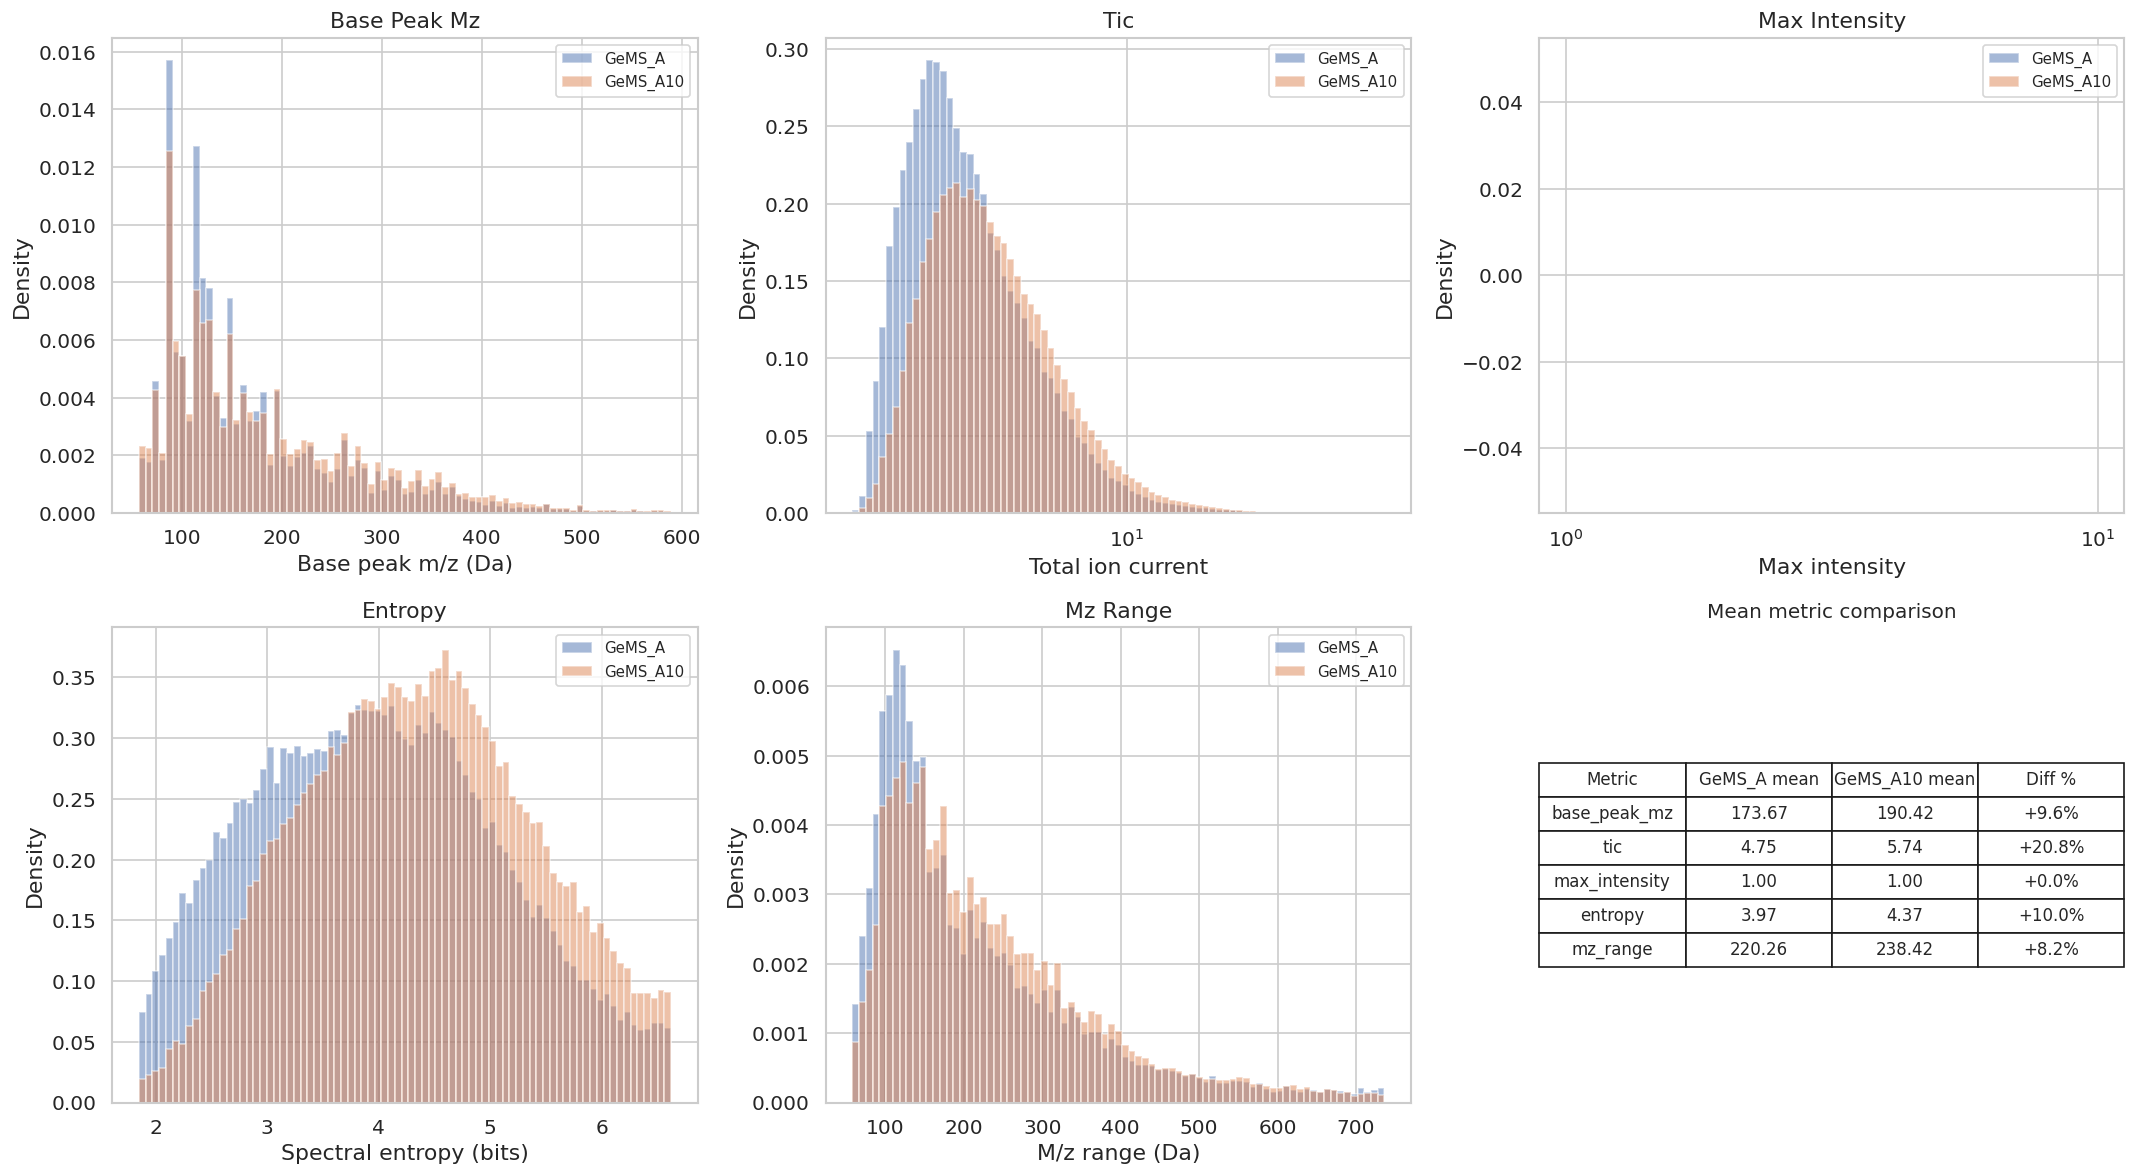

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metric_configs = [
    ("base_peak_mz", "Base peak m/z (Da)", None),
    ("tic", "Total ion current", "log"),
    ("max_intensity", "Max intensity", "log"),
    ("entropy", "Spectral entropy (bits)", None),
    ("mz_range", "M/z range (Da)", None),
]

for i, (key, xlabel, xscale) in enumerate(metric_configs):
    ax = axes.flat[i]
    vals_a = metrics_a[key]
    vals_10 = metrics_10[key]
    
    if xscale == "log":
        valid_a = vals_a[vals_a > 0]
        valid_10 = vals_10[vals_10 > 0]
        bins = np.logspace(np.log10(max(valid_a.min(), 1e-6)),
                           np.log10(valid_a.max()), 80)
        ax.hist(valid_a, bins=bins, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
        ax.hist(valid_10, bins=bins, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
        ax.set_xscale("log")
    else:
        p1, p99 = np.percentile(np.concatenate([vals_a, vals_10]), [1, 99])
        bins = np.linspace(p1, p99, 80)
        ax.hist(vals_a, bins=bins, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
        ax.hist(vals_10, bins=bins, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(key.replace("_", " ").title())
    ax.legend(fontsize=9)

# Last subplot: summary table
ax = axes.flat[-1]
ax.axis("off")
summary_data = []
for key, xlabel, _ in metric_configs:
    summary_data.append([
        key,
        f"{metrics_a[key].mean():.2f}",
        f"{metrics_10[key].mean():.2f}",
        f"{(metrics_10[key].mean() - metrics_a[key].mean()) / (metrics_a[key].mean() + 1e-12) * 100:+.1f}%",
    ])
table = ax.table(
    cellText=summary_data,
    colLabels=["Metric", "GeMS_A mean", "GeMS_A10 mean", "Diff %"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax.set_title("Mean metric comparison", fontsize=12)

fig.tight_layout()
plt.show()

## 8. Pipeline Processing Comparison

Apply the same processing logic from `input_pipeline.py` to both datasets and compare outputs.
The pipeline: filter precursor m/z -> filter peak m/z range -> filter min intensity -> top-k -> sort -> normalize.

In [15]:
# Replicate pipeline processing in NumPy (matching input_pipeline.py logic)
PEAK_MZ_MIN = 20.0
PEAK_MZ_MAX = 1000.0
MAX_PRECURSOR_MZ = 1000.0
PRECURSOR_WINDOW = 2.5
MIN_INTENSITY = 1e-4
NUM_PEAKS = 60

def process_spectrum_batch(
    spectra: np.ndarray,
    precursor_mz: np.ndarray,
) -> dict[str, np.ndarray]:
    """Replicate the pipeline processing from input_pipeline.py."""
    mz = spectra[:, 0, :].copy()          # [N, P]
    intensity = spectra[:, 1, :].copy()    # [N, P]
    
    # Filter peak m/z range
    upper = np.where(precursor_mz > 0, precursor_mz - PRECURSOR_WINDOW, PEAK_MZ_MAX)
    keep = (mz >= PEAK_MZ_MIN) & (mz <= upper[:, None])
    mz = np.where(keep, mz, 0.0)
    intensity = np.where(keep, intensity, 0.0)
    
    # Filter min intensity
    keep2 = intensity >= MIN_INTENSITY
    mz = np.where(keep2, mz, 0.0)
    intensity = np.where(keep2, intensity, 0.0)
    
    # Top-k peaks by intensity
    if mz.shape[1] > NUM_PEAKS:
        top_idx = np.argpartition(-intensity, NUM_PEAKS, axis=1)[:, :NUM_PEAKS]
        row_idx = np.arange(len(mz))[:, None]
        mz = mz[row_idx, top_idx]
        intensity = intensity[row_idx, top_idx]
    
    # Sort by m/z (invalid peaks get inf)
    valid = intensity > 0
    sort_key = np.where(valid, mz, np.inf)
    sort_idx = np.argsort(sort_key, axis=1)
    row_idx = np.arange(len(mz))[:, None]
    mz = mz[row_idx, sort_idx]
    intensity = intensity[row_idx, sort_idx]
    valid = valid[row_idx, sort_idx]
    mz = np.where(valid, mz, 0.0)
    intensity = np.where(valid, intensity, 0.0)
    
    # Normalize
    peak_mz_norm = mz / PEAK_MZ_MAX
    precursor_mz_norm = np.clip(precursor_mz, 0, MAX_PRECURSOR_MZ) / MAX_PRECURSOR_MZ
    
    valid_count = valid.sum(axis=1)
    
    return {
        "peak_mz": peak_mz_norm,
        "peak_intensity": intensity,
        "peak_valid_mask": valid,
        "precursor_mz": precursor_mz_norm,
        "valid_peak_count": valid_count,
    }

# Process both samples
proc_a = process_spectrum_batch(spec_a, prec_a[idx_a])
proc_10 = process_spectrum_batch(spec_10, prec_10[idx_10])

print("Processed both samples through pipeline logic.")
for key in proc_a:
    print(f"  {key}: GeMS_A={proc_a[key].shape}, GeMS_A10={proc_10[key].shape}")

Processed both samples through pipeline logic.
  peak_mz: GeMS_A=(100000, 60), GeMS_A10=(100000, 60)
  peak_intensity: GeMS_A=(100000, 60), GeMS_A10=(100000, 60)
  peak_valid_mask: GeMS_A=(100000, 60), GeMS_A10=(100000, 60)
  precursor_mz: GeMS_A=(100000,), GeMS_A10=(100000,)
  valid_peak_count: GeMS_A=(100000,), GeMS_A10=(100000,)


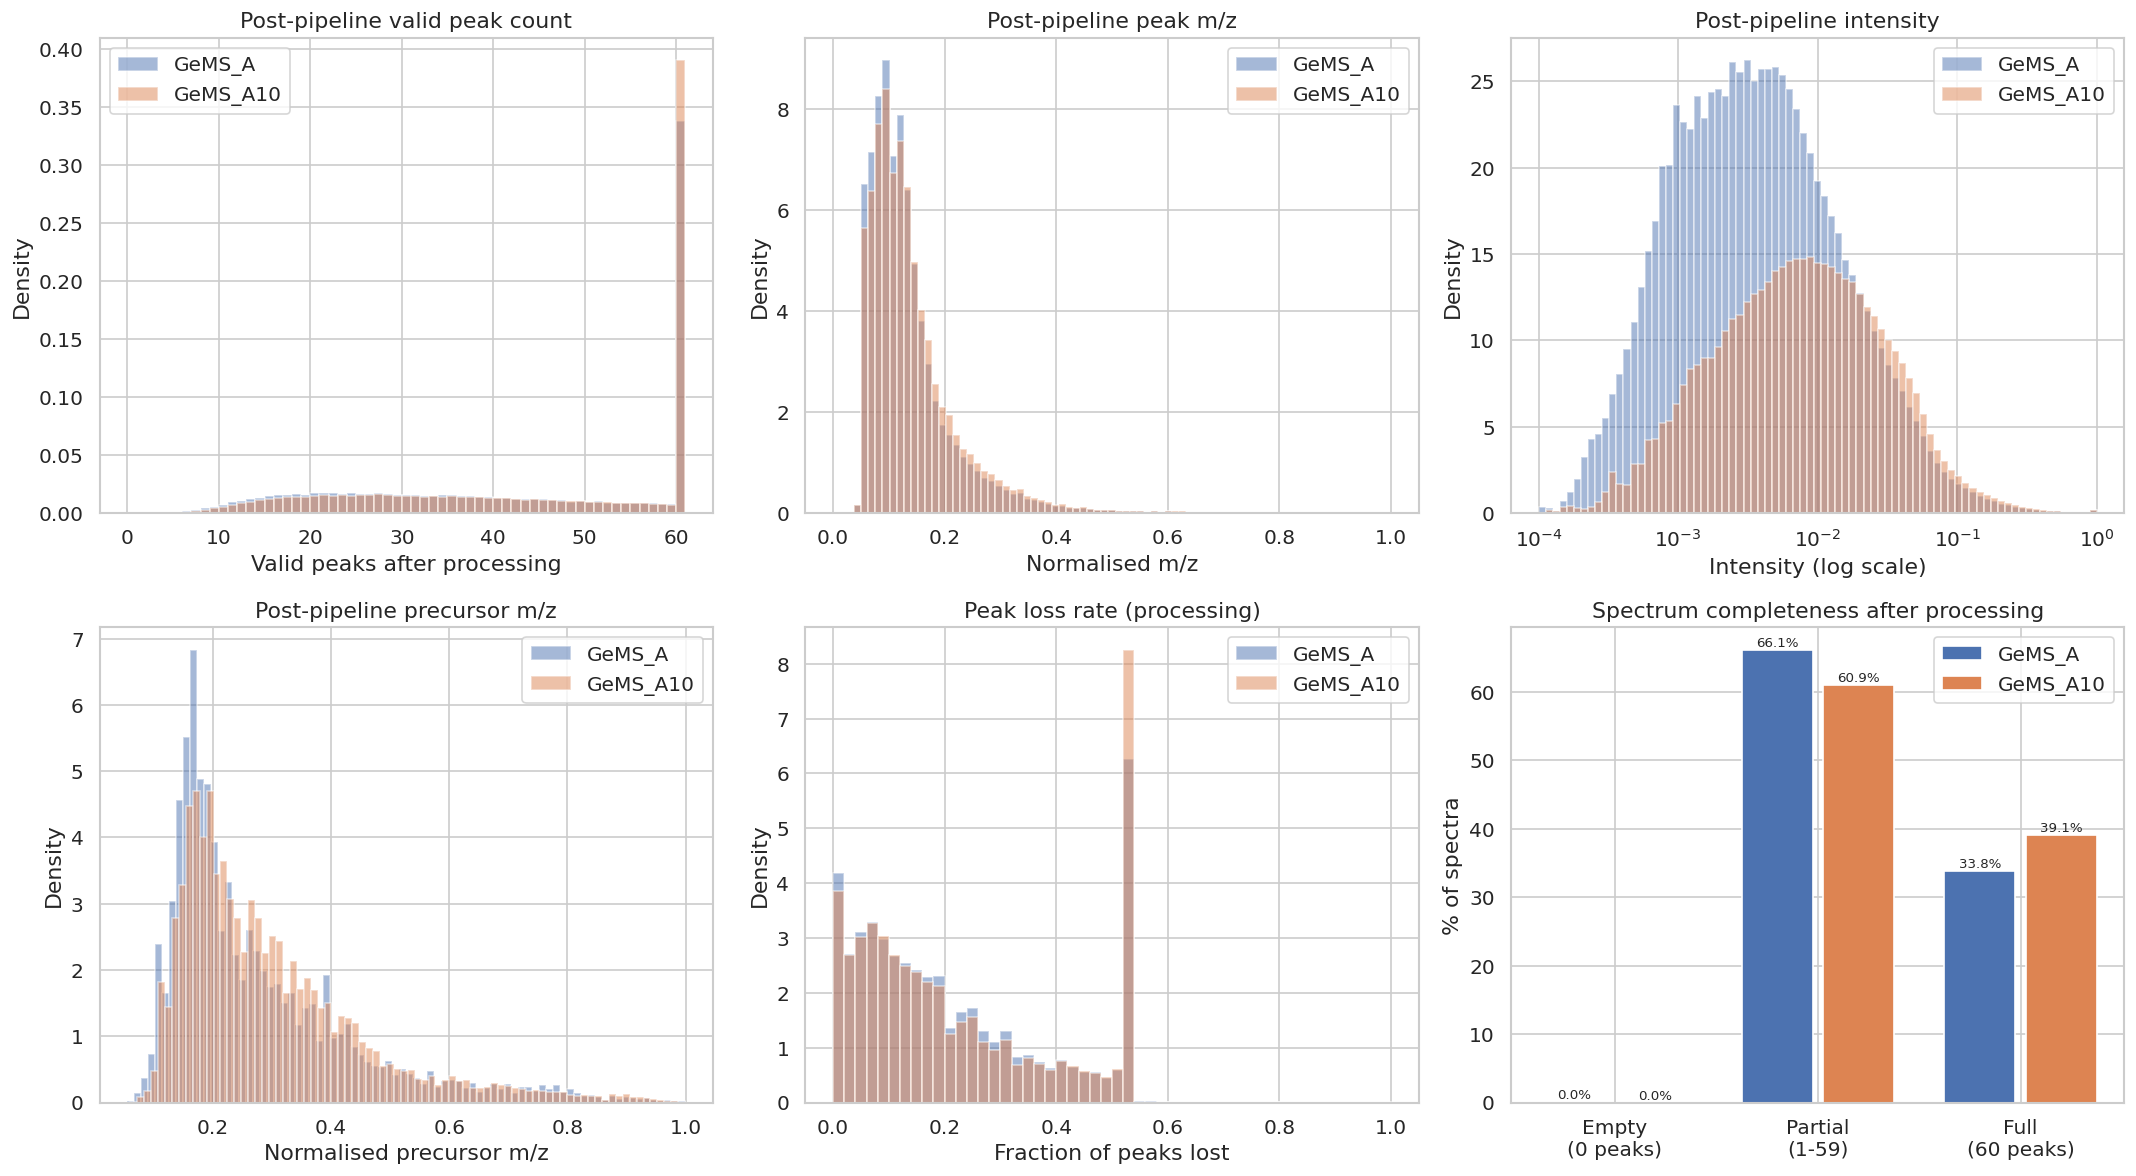

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (0,0) Valid peak count after processing
ax = axes[0, 0]
bins_vpc = np.arange(0, 62)
ax.hist(proc_a["valid_peak_count"], bins=bins_vpc, alpha=0.5, density=True,
        label="GeMS_A", color="#4C72B0")
ax.hist(proc_10["valid_peak_count"], bins=bins_vpc, alpha=0.5, density=True,
        label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Valid peaks after processing")
ax.set_ylabel("Density")
ax.set_title("Post-pipeline valid peak count")
ax.legend()

# (0,1) Processed peak m/z distribution
ax = axes[0, 1]
pmz_a = proc_a["peak_mz"][proc_a["peak_valid_mask"]]
pmz_10 = proc_10["peak_mz"][proc_10["peak_valid_mask"]]
if len(pmz_a) > 500_000:
    pmz_a = np.random.choice(pmz_a, 500_000, replace=False)
if len(pmz_10) > 500_000:
    pmz_10 = np.random.choice(pmz_10, 500_000, replace=False)
bins_pmz = np.linspace(0, 1, 80)
ax.hist(pmz_a, bins=bins_pmz, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(pmz_10, bins=bins_pmz, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Normalised m/z")
ax.set_ylabel("Density")
ax.set_title("Post-pipeline peak m/z")
ax.legend()

# (0,2) Processed intensity distribution
ax = axes[0, 2]
pint_a = proc_a["peak_intensity"][proc_a["peak_valid_mask"]]
pint_10 = proc_10["peak_intensity"][proc_10["peak_valid_mask"]]
if len(pint_a) > 500_000:
    pint_a = np.random.choice(pint_a, 500_000, replace=False)
if len(pint_10) > 500_000:
    pint_10 = np.random.choice(pint_10, 500_000, replace=False)
log_bins_int = np.logspace(np.log10(MIN_INTENSITY), np.log10(max(pint_a.max(), pint_10.max())), 80)
ax.hist(pint_a, bins=log_bins_int, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(pint_10, bins=log_bins_int, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xscale("log")
ax.set_xlabel("Intensity (log scale)")
ax.set_ylabel("Density")
ax.set_title("Post-pipeline intensity")
ax.legend()

# (1,0) Precursor m/z after normalization
ax = axes[1, 0]
ax.hist(proc_a["precursor_mz"], bins=80, alpha=0.5, density=True,
        label="GeMS_A", color="#4C72B0")
ax.hist(proc_10["precursor_mz"], bins=80, alpha=0.5, density=True,
        label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Normalised precursor m/z")
ax.set_ylabel("Density")
ax.set_title("Post-pipeline precursor m/z")
ax.legend()

# (1,1) Peak loss rate (how many peaks lost in processing)
ax = axes[1, 1]
raw_peaks_a = count_valid_peaks(spec_a)
raw_peaks_10 = count_valid_peaks(spec_10)
loss_rate_a = 1.0 - proc_a["valid_peak_count"] / np.clip(raw_peaks_a, 1, None)
loss_rate_10 = 1.0 - proc_10["valid_peak_count"] / np.clip(raw_peaks_10, 1, None)

ax.hist(loss_rate_a, bins=50, alpha=0.5, density=True, label="GeMS_A", color="#4C72B0")
ax.hist(loss_rate_10, bins=50, alpha=0.5, density=True, label="GeMS_A10", color="#DD8452")
ax.set_xlabel("Fraction of peaks lost")
ax.set_ylabel("Density")
ax.set_title("Peak loss rate (processing)")
ax.legend()

# (1,2) Empty spectra after processing
ax = axes[1, 2]
empty_a = (proc_a["valid_peak_count"] == 0).mean() * 100
empty_10 = (proc_10["valid_peak_count"] == 0).mean() * 100
saturated_a = (proc_a["valid_peak_count"] == NUM_PEAKS).mean() * 100
saturated_10 = (proc_10["valid_peak_count"] == NUM_PEAKS).mean() * 100

categories = ["Empty\n(0 peaks)", "Partial\n(1-59)", "Full\n(60 peaks)"]
vals_a = [empty_a, 100 - empty_a - saturated_a, saturated_a]
vals_10 = [empty_10, 100 - empty_10 - saturated_10, saturated_10]

x = np.arange(len(categories))
ax.bar(x - 0.2, vals_a, 0.35, label="GeMS_A", color="#4C72B0")
ax.bar(x + 0.2, vals_10, 0.35, label="GeMS_A10", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("% of spectra")
ax.set_title("Spectrum completeness after processing")
ax.legend()
for i, (va, v10) in enumerate(zip(vals_a, vals_10)):
    ax.text(i - 0.2, va + 0.5, f"{va:.1f}%", ha="center", fontsize=8)
    ax.text(i + 0.2, v10 + 0.5, f"{v10:.1f}%", ha="center", fontsize=8)

fig.tight_layout()
plt.show()

## 9. Example Spectra Comparison

Visualise a few random processed spectra from each dataset.

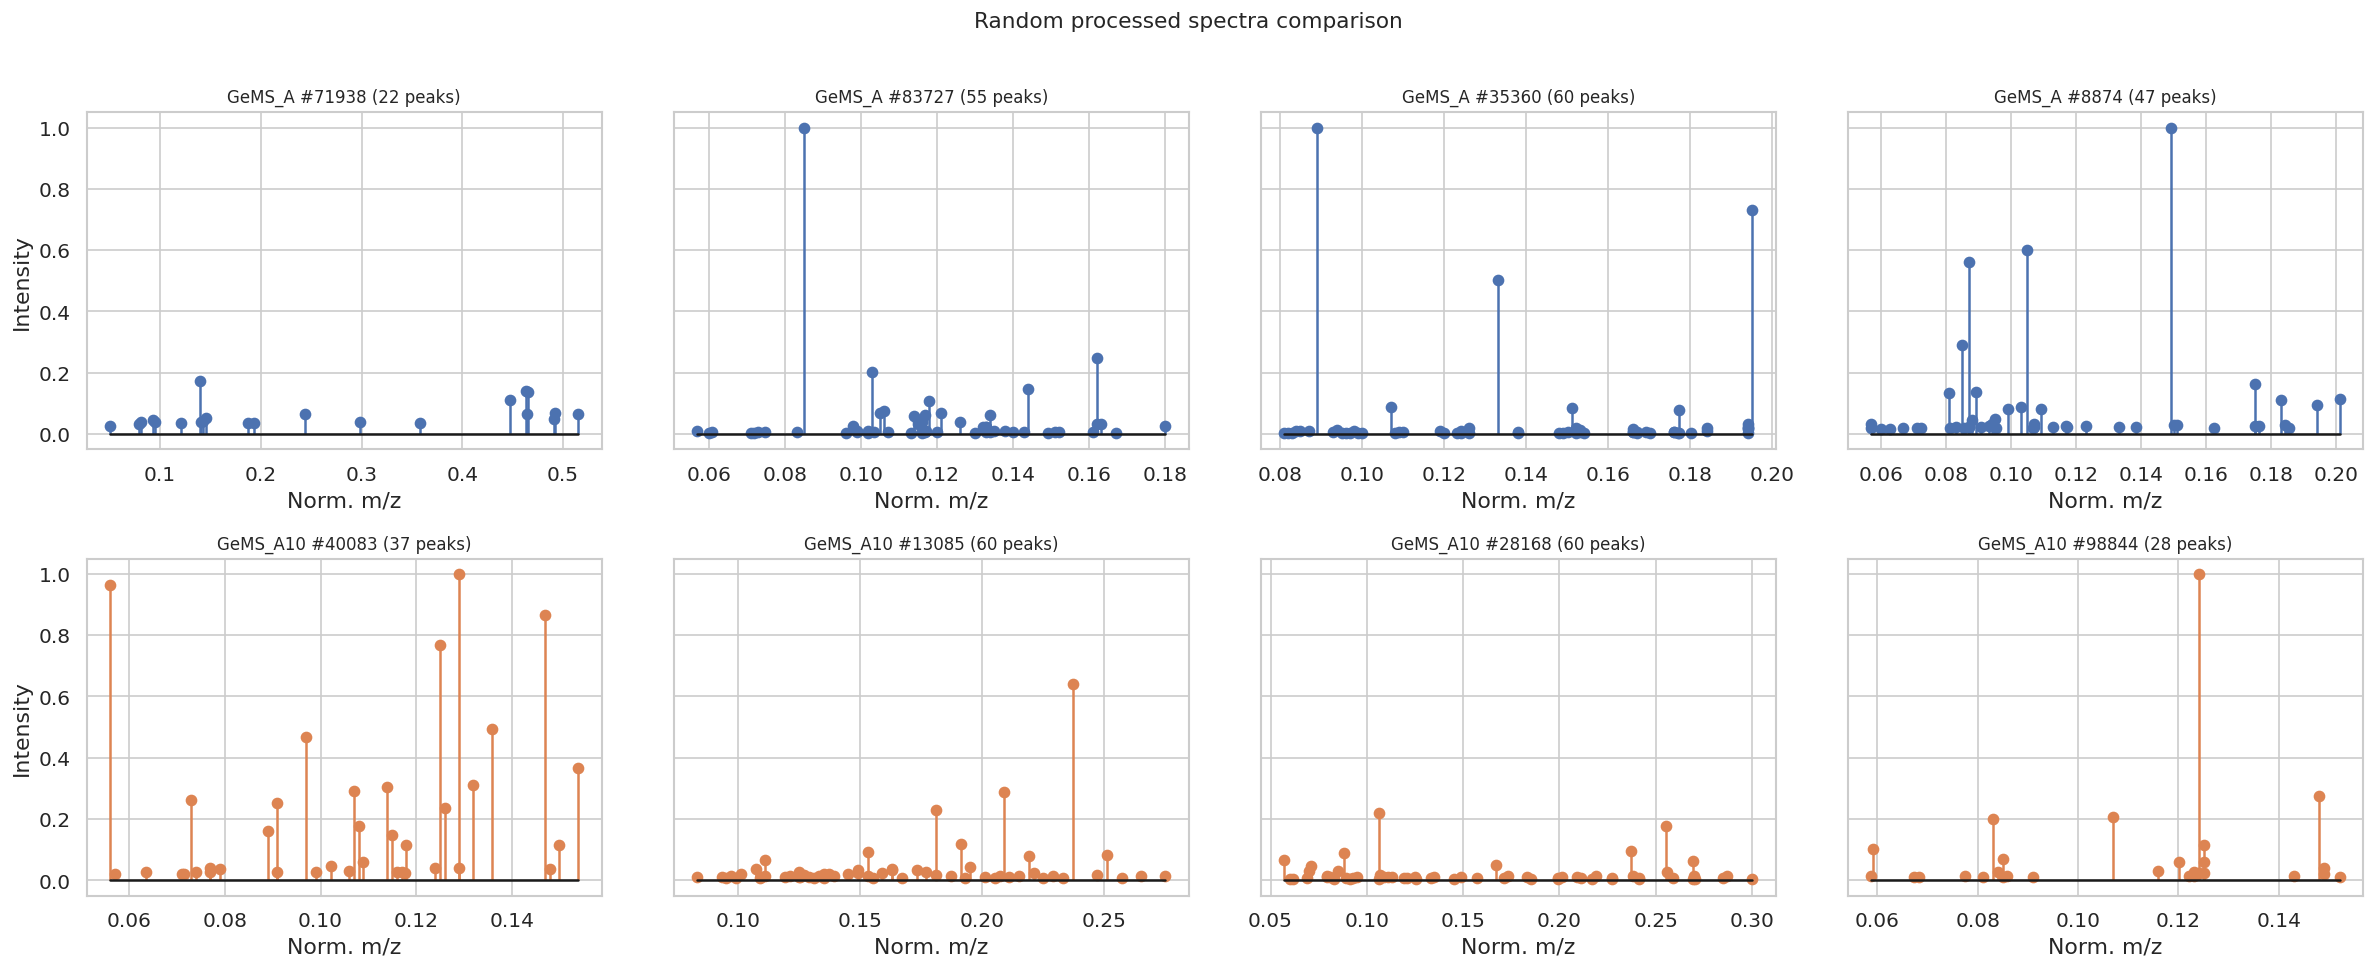

In [17]:
NUM_EXAMPLES = 4
fig, axes = plt.subplots(2, NUM_EXAMPLES, figsize=(5 * NUM_EXAMPLES, 8), sharey="row")

# Pick spectra with decent peak counts
good_a = np.where(proc_a["valid_peak_count"] >= 20)[0]
good_10 = np.where(proc_10["valid_peak_count"] >= 20)[0]
sample_a = np.random.choice(good_a, NUM_EXAMPLES, replace=False)
sample_10 = np.random.choice(good_10, NUM_EXAMPLES, replace=False)

for col in range(NUM_EXAMPLES):
    # GeMS_A
    i = sample_a[col]
    mask = proc_a["peak_valid_mask"][i]
    axes[0, col].stem(
        proc_a["peak_mz"][i][mask], proc_a["peak_intensity"][i][mask],
        linefmt="C0-", markerfmt="C0o", basefmt="k-",
    )
    axes[0, col].set_title(f"GeMS_A #{i} ({mask.sum()} peaks)", fontsize=10)
    axes[0, col].set_xlabel("Norm. m/z")
    
    # GeMS_A10
    j = sample_10[col]
    mask10 = proc_10["peak_valid_mask"][j]
    axes[1, col].stem(
        proc_10["peak_mz"][j][mask10], proc_10["peak_intensity"][j][mask10],
        linefmt="C1-", markerfmt="C1o", basefmt="k-",
    )
    axes[1, col].set_title(f"GeMS_A10 #{j} ({mask10.sum()} peaks)", fontsize=10)
    axes[1, col].set_xlabel("Norm. m/z")

axes[0, 0].set_ylabel("Intensity")
axes[1, 0].set_ylabel("Intensity")

fig.suptitle("Random processed spectra comparison", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 10. Additional Keys in GeMS_A10

Check if GeMS_A10 has additional fields not present in GeMS_A (e.g. cluster IDs, DreaMS embeddings).

In [18]:
keys_a = set(fa.keys())
keys_10 = set(f10.keys())

shared = keys_a & keys_10
only_a = keys_a - keys_10
only_10 = keys_10 - keys_a

print(f"Shared keys ({len(shared)}): {sorted(shared)}")
print(f"Only in GeMS_A ({len(only_a)}): {sorted(only_a)}")
print(f"Only in GeMS_A10 ({len(only_10)}): {sorted(only_10)}")

if only_10:
    print("\nAdditional GeMS_A10 fields:")
    for key in sorted(only_10):
        ds = f10[key]
        print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")
        # Show sample values for small fields
        if ds.ndim <= 1 and ds.shape[0] <= 10:
            print(f"    values: {ds[:]}")
        elif ds.ndim == 1:
            print(f"    first 5: {ds[:5]}")
            print(f"    unique count: {len(np.unique(ds[:min(100000, len(ds))]))}")

Shared keys (6): ['RT', 'charge', 'instrument accuracy est.', 'name', 'precursor_mz', 'spectrum']
Only in GeMS_A (0): []
Only in GeMS_A10 (1): ['lsh']

Additional GeMS_A10 fields:
  lsh: shape=(23517534,), dtype=int64
    first 5: [-9223212298006653272 -9223212298006653272 -9223212298006653272
 -9223212298006653272 -9223212298006653272]
    unique count: 10000


## 11. Summary

In [19]:
print("=" * 70)
print("GeMS_A vs GeMS_A10 Comparison Summary")
print("=" * 70)
print(f"")
print(f"{'Metric':<35s} {'GeMS_A':>15s} {'GeMS_A10':>15s}")
print(f"{'-'*35} {'-'*15} {'-'*15}")
print(f"{'Total spectra':<35s} {n_a:>15,} {n_10:>15,}")
print(f"{'File size (GB)':<35s} {GEMS_A_PATH.stat().st_size/1e9:>15.2f} {GEMS_A10_PATH.stat().st_size/1e9:>15.2f}")
print(f"{'Dedup ratio (A10/A)':<35s} {'':>15s} {n_10/n_a*100:>14.1f}%")
print(f"{'HDF5 keys':<35s} {str(sorted(keys_a)):>15s} {str(sorted(keys_10)):>15s}")
print(f"")
print(f"{'Valid RT spectra (%)':<35s} {len(valid_rt_a)/n_a*100:>14.1f}% {len(valid_rt_10)/n_10*100:>14.1f}%")
print(f"{'Precursor mz <= 1000 Da (%)':<35s} {(prec_a<=1000).mean()*100:>14.1f}% {(prec_10<=1000).mean()*100:>14.1f}%")
print(f"{'Mean peak count (raw)':<35s} {peaks_a.mean():>15.1f} {peaks_10.mean():>15.1f}")
print(f"{'Mean peak count (processed)':<35s} {proc_a['valid_peak_count'].mean():>15.1f} {proc_10['valid_peak_count'].mean():>15.1f}")
print(f"{'Spectra with 60 peaks (processed)':<35s} {saturated_a:>14.1f}% {saturated_10:>14.1f}%")
print(f"{'Empty spectra (processed)':<35s} {empty_a:>14.2f}% {empty_10:>14.2f}%")
print(f"{'Mean spectral entropy (bits)':<35s} {metrics_a['entropy'].mean():>15.2f} {metrics_10['entropy'].mean():>15.2f}")
print(f"{'Mean m/z range (Da)':<35s} {metrics_a['mz_range'].mean():>15.1f} {metrics_10['mz_range'].mean():>15.1f}")
print(f"")
print(f"Keys only in GeMS_A10: {sorted(only_10) if only_10 else 'None'}")
print(f"Keys only in GeMS_A:   {sorted(only_a) if only_a else 'None'}")
print("=" * 70)

# Close HDF5 files
fa.close()
f10.close()
print("\nClosed HDF5 files.")

GeMS_A vs GeMS_A10 Comparison Summary

Metric                                       GeMS_A        GeMS_A10
----------------------------------- --------------- ---------------
Total spectra                            41,951,922      23,517,534
File size (GB)                                24.45           14.63
Dedup ratio (A10/A)                                           56.1%
HDF5 keys                           ['RT', 'charge', 'instrument accuracy est.', 'name', 'precursor_mz', 'spectrum'] ['RT', 'charge', 'instrument accuracy est.', 'lsh', 'name', 'precursor_mz', 'spectrum']

Valid RT spectra (%)                         100.0%          100.0%
Precursor mz <= 1000 Da (%)                  100.0%          100.0%
Mean peak count (raw)                          59.1            63.9
Mean peak count (processed)                    41.3            43.4
Spectra with 60 peaks (processed)             33.8%           39.1%
Empty spectra (processed)                     0.01%           0.00%
Mean sp